# RiverScope: Replicating DPT Results (vitb_clip & vitl)

**Paper:** [RiverScope: High-Resolution River Masking Dataset (arXiv 2509.02451)](https://arxiv.org/abs/2509.02451)  
**Repo:** [cvl-umass/riverscope-models](https://github.com/cvl-umass/riverscope-models)  

This notebook replicates the two DPT model configurations:
- **DPT + ViT-B/16 + CLIP** → Expected F1: **93.30 ± 0.73**, threshold: **0.3**
- **DPT + ViT-L/16 + ImageNet1k** → Expected F1: **92.88 ± 0.54**, threshold: **0.2**

---
### ⚠️ Requirements
- **GPU with ≥16 GB VRAM** (A100/V100 recommended for vitl; T4 may OOM)
- **Google Drive** with RiverScope dataset and checkpoints mounted
- Runtime: **GPU** (Runtime → Change runtime type → GPU)

## 1. Mount Google Drive & Set Paths

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# ── EDIT THESE to match your Drive layout ──────────────────────────────────
RIVERSCOPE_DATASET_DIR = '/content/drive/MyDrive/CS682/project/RiverScope_dataset'   # path to PlanetScope data
CKPT_VITB_CLIP = '/content/drive/MyDrive/CS682/project/checkpoints/dpt_vitb_clip_best.pth.tar'  # checkpoint for vitb_clip
CKPT_VITL     = '/content/drive/MyDrive/CS682/project/checkpoints/dpt_vitl_best.pth.tar'        # checkpoint for vitl
# ───────────────────────────────────────────────────────────────────────────

# Verify GPU
import subprocess
result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
                       capture_output=True, text=True)
print('GPU:', result.stdout.strip())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU: Tesla T4, 15360 MiB


## 2. Clone the Repository

In [2]:
import os

REPO_DIR = '/content/drive/MyDrive/CS682/project/riverscope-models'

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/cvl-umass/riverscope-models {REPO_DIR}
else:
    print('Repo already cloned, pulling latest...')
    !cd {REPO_DIR} && git pull

%cd {REPO_DIR}
!ls

Repo already cloned, pulling latest...
Already up to date.
/content/drive/MyDrive/CS682/project/riverscope-models
assets	     models	       river_width_estimate.py	  utils_dir
checkpoints  README.md	       script_train_planet.sh	  water_eval_planet.py
data	     requirements.txt  train_planet.py
dataset      results	       train_satlas_sentinel2.py


## 3. Install Dependencies

The repo pins to CUDA 12.6 wheels. Colab (as of 2025) typically ships CUDA 12.x, so this should be compatible. If you hit CUDA version errors, see the troubleshooting cell at the bottom.

In [6]:
# Install all requirements from repo
# Note: segmentation_models_pytorch is installed from source (v0.5.0 git)
!pip install -q -r requirements.txt

# Verify torch + CUDA
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.3 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.3 which is incompatible.
access 1.1.10.post3 requires scipy>=1.14.1, but you have scipy 1.13.1 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.3 which is incompatible.
pointpats 2.5.5 requires shapely>=2.1, but you have shapely 2.0.7 which is incompatible.
spopt 0.7.0 requires shapely>=2.1.0, but you have shapely 2.0.7 which is incompatible.
tsfresh 0.21.1 requires scipy>=1.14.0; python_version >= "3.10", bu

## 4. Download Pre-trained Checkpoints

The checkpoints are hosted on Google Drive (public links from the repo README).

| Model | Backbone | Checkpoint GDrive ID | Threshold |
|-------|----------|---------------------|-----------|
| dpt | vitb_clip | `1fIQxyfJFNf9Q2sll4SHc8VWKDmVESZVB` | 0.3 |
| dpt | vitl | `1FR_kuV0P7MG1dXlHTuHq-Utmev_dVMZz` | 0.2 |

Run this cell to auto-download them, **OR** if you already have them in Drive, skip to cell after next.

In [4]:
import os

CKPT_DIR = '/content/drive/MyDrive/CS682/project/riverscope-models/checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)

# Install gdown if needed
!pip install -q gdown
import gdown

# ── vitb_clip checkpoint ──
vitb_clip_id   = '1fIQxyfJFNf9Q2sll4SHc8VWKDmVESZVB'
vitb_clip_path = os.path.join(CKPT_DIR, 'dpt_vitb_clip_best.pth.tar')
if not os.path.exists(vitb_clip_path):
    print('Downloading dpt vitb_clip checkpoint...')
    gdown.download(id=vitb_clip_id, output=vitb_clip_path, quiet=False)
else:
    print(f'vitb_clip checkpoint found: {vitb_clip_path}')

# ── vitl checkpoint ──
vitl_id   = '1FR_kuV0P7MG1dXlHTuHq-Utmev_dVMZz'
vitl_path = os.path.join(CKPT_DIR, 'dpt_vitl_best.pth.tar')
if not os.path.exists(vitl_path):
    print('Downloading dpt vitl checkpoint...')
    gdown.download(id=vitl_id, output=vitl_path, quiet=False)
else:
    print(f'vitl checkpoint found: {vitl_path}')

# Update path variables to the downloaded checkpoints
CKPT_VITB_CLIP = vitb_clip_path
CKPT_VITL = vitl_path

print(f'\nvitb_clip ckpt: {CKPT_VITB_CLIP} ({os.path.getsize(CKPT_VITB_CLIP)/1e6:.1f} MB)')
print(f'vitl ckpt:      {CKPT_VITL} ({os.path.getsize(CKPT_VITL)/1e6:.1f} MB)')

vitb_clip checkpoint found: /content/drive/MyDrive/CS682/project/riverscope-models/checkpoints/dpt_vitb_clip_best.pth.tar
vitl checkpoint found: /content/drive/MyDrive/CS682/project/riverscope-models/checkpoints/dpt_vitl_best.pth.tar

vitb_clip ckpt: /content/drive/MyDrive/CS682/project/riverscope-models/checkpoints/dpt_vitb_clip_best.pth.tar (1454.2 MB)
vitl ckpt:      /content/drive/MyDrive/CS682/project/riverscope-models/checkpoints/dpt_vitl_best.pth.tar (4115.6 MB)


## 5. Verify Dataset Layout

The RiverScope PlanetScope dataset should have this structure:
```
RiverScope_dataset/
├── train.csv          ← columns: normalized_planetscope_path, label_path, ...
├── valid.csv
├── test.csv
└── PlanetScope/
    ├── input/
    │   ├── train/
    │   ├── valid/
    │   └── test/
    └── label/
        ├── train/
        ├── valid/
        └── test/
```
Download from: https://github.com/cvl-umass/riverscope (Zenodo DOI: 10.5281/zenodo.15376394)

In [8]:
# Fix for numpy/pandas incompatibility
!pip uninstall pandas -y
!pip uninstall numpy -y
!pip install numpy==1.26.3
!pip install pandas==2.2.2

Found existing installation: pandas 2.2.3
Uninstalling pandas-2.2.3:
  Successfully uninstalled pandas-2.2.3
Found existing installation: numpy 1.26.3
Uninstalling numpy-1.26.3:
  Successfully uninstalled numpy-1.26.3
  Using cached numpy-1.26.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
geopandas 1.0.1 requires pandas>=1.4.0, which is not installed.
tobler 0.14.0 requires pandas>=2.2, which is not installed.
access 1.1.10.post3 requires pandas>=2.1.0, which is not installed.
holoviews 1.22.1 requires pandas>=1.3, which is not installed.
shap 0.51.0 requires pandas, which is not installed.
pointpats 2.5.5 requires pandas>=2.2, which is not installed.
tensorflow-decision-forests 1.12.0 req

  Using cached pandas-2.2.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (19 kB)
Using cached pandas-2.2.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.7 MB)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
^C


In [7]:
import os, glob
import pandas as pd

PLANET_DIR = os.path.join(RIVERSCOPE_DATASET_DIR, 'PlanetScope')

# 1. Check CSV manifests exist and show sample paths
print('── CSV manifests ──')
for split in ['train', 'valid', 'test']:
    csv_path = os.path.join(RIVERSCOPE_DATASET_DIR, f'{split}.csv')
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        print(f'  {split}.csv  →  {len(df)} rows')
        print(f'    input : {df["normalized_planetscope_path"].iloc[0]}')
        print(f'    label : {df["label_path"].iloc[0]}')
    else:
        print(f'  *** MISSING: {csv_path} ***')

print()

# 2. Count .tif files in input/ and label/ trees
print('── File counts ──')
for folder in ['input', 'label']:
    for split in ['train', 'valid', 'test']:
        d = os.path.join(PLANET_DIR, folder, split)
        n = len(glob.glob(os.path.join(d, '**', '*.tif'), recursive=True))
        status = f'{n} .tif files' if os.path.exists(d) else '*** NOT FOUND ***'
        print(f'  PlanetScope/{folder}/{split}/  →  {status}')

print()

# 3. Confirm CSV relative paths actually resolve to real files
print('── Resolving sample paths from test.csv ──')
df_test = pd.read_csv(os.path.join(RIVERSCOPE_DATASET_DIR, 'test.csv'))
sample_img   = os.path.join(RIVERSCOPE_DATASET_DIR, df_test['normalized_planetscope_path'].iloc[0])
sample_label = os.path.join(RIVERSCOPE_DATASET_DIR, df_test['label_path'].iloc[0])
print(f'  input exists : {os.path.exists(sample_img)}   {sample_img}')
print(f'  label exists : {os.path.exists(sample_label)}   {sample_label}')

── CSV manifests ──
  train.csv  →  787 rows
    input : PlanetScope/input/train/20230615_073020_13_24c8_3B_AnalyticMS_SR_clip-tile_166_666-774-1274.tif
    label : PlanetScope/label/train/20230615_073020_13_24c8_3B_AnalyticMS_SR_clip-tile_166_666-774-1274.tif
  valid.csv  →  123 rows
    input : PlanetScope/input/valid/20230623_180235_54_2429_3B_AnalyticMS_SR_clip-tile_2057_2557-1031-1531_mid.tif
    label : PlanetScope/label/valid/20230623_180235_54_2429_3B_AnalyticMS_SR_clip-tile_2057_2557-1031-1531_mid.tif
  test.csv  →  235 rows
    input : PlanetScope/input/test/20230615_134909_40_2424_3B_AnalyticMS_SR_clip-tile_1202_1702-967-1467_mid.tif
    label : PlanetScope/label/test/20230615_134909_40_2424_3B_AnalyticMS_SR_clip-tile_1202_1702-967-1467_mid.tif

── File counts ──
  PlanetScope/input/train/  →  787 .tif files
  PlanetScope/input/valid/  →  123 .tif files
  PlanetScope/input/test/  →  235 .tif files
  PlanetScope/label/train/  →  787 .tif files
  PlanetScope/label/valid/  →  1

## 6. Inspect Checkpoint Metadata

Each checkpoint stores the training options used. This is critical — the eval script reads `ckpt_opt` to reconstruct the model identically.

In [8]:
import torch

def inspect_checkpoint(ckpt_path, label):
    print(f'\n══════════ {label} ══════════')
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    print(f'  Keys: {list(ckpt.keys())}')
    print(f'  Epoch:            {ckpt.get("epoch", "N/A")}')
    print(f'  Best performance: {ckpt.get("best_performance", "N/A")}')
    opt = ckpt.get('opt')
    if opt:
        print(f'  segment_model:  {opt.segment_model}')
        print(f'  backbone:       {opt.backbone}')
        print(f'  head:           {opt.head}')
        print(f'  resize_size:    {opt.resize_size}')
        print(f'  adaptor:        {opt.adaptor}')
        print(f'  lr:             {opt.lr}')
    param_count = sum(v.numel() for v in ckpt['state_dict'].values())
    print(f'  Parameters:     {param_count/1e6:.1f} M')

inspect_checkpoint(CKPT_VITB_CLIP, 'DPT vitb_clip')
inspect_checkpoint(CKPT_VITL,      'DPT vitl')


══════════ DPT vitb_clip ══════════
  Keys: ['epoch', 'state_dict', 'best_performance', 'cur_performance', 'optimizer', 'opt', 'scheduler']
  Epoch:            50
  Best performance: 0.9002129435539246
  segment_model:  dpt
  backbone:       vitb_clip
  head:           no_head
  resize_size:    224
  adaptor:        linear
  lr:             1e-05
  Parameters:     121.4 M

══════════ DPT vitl ══════════
  Keys: ['epoch', 'state_dict', 'best_performance', 'cur_performance', 'optimizer', 'opt', 'scheduler']
  Epoch:            29
  Best performance: 0.9016017913818359
  segment_model:  dpt
  backbone:       vitl
  head:           no_head
  resize_size:    224
  adaptor:        linear
  lr:             0.0001
  Parameters:     342.9 M


## 7. Evaluate: DPT + ViT-B/16 + CLIP

**Expected results (paper Table):**
- F1: **93.30 ± 0.73**
- Precision: **92.29 ± 1.22**
- Recall: **94.36 ± 1.06**
- Optimal threshold: **0.3**

Using the pre-defined threshold (0.3) to skip val-set search and speed up eval.
Remove `--thresh 0.3` to auto-find threshold from validation set (slower, ~2x runtime).

In [9]:
import subprocess, sys

cmd = [
    sys.executable, 'water_eval_planet.py',
    '--data_dir', RIVERSCOPE_DATASET_DIR,
    '--ckpt_path', CKPT_VITB_CLIP,
    '--thresh', '0.3',          # paper-reported optimal threshold; remove to auto-search
    '--batch_size', '8',        # reduce to 4 if OOM on T4
    '--to_save_imgs', '1',      # set to 1 to save segmentation masks
    '--out', './results/planet-test-eval',
]

print('Running evaluation for DPT vitb_clip...')
print('Command:', ' '.join(cmd))
print('-' * 60)

result = subprocess.run(cmd, capture_output=False, text=True)
print('Return code:', result.returncode)

Running evaluation for DPT vitb_clip...
Command: /usr/bin/python3 water_eval_planet.py --data_dir /content/drive/MyDrive/CS682/project/RiverScope_dataset --ckpt_path /content/drive/MyDrive/CS682/project/riverscope-models/checkpoints/dpt_vitb_clip_best.pth.tar --thresh 0.3 --batch_size 8 --to_save_imgs 0 --out ./results/planet-test-eval
------------------------------------------------------------
Return code: 0


## 8. Evaluate: DPT + ViT-L/16 + ImageNet1k

**Expected results (paper Table):**
- F1: **92.88 ± 0.54**
- Precision: **90.01 ± 0.27**
- Recall: **95.94 ± 0.87**
- Optimal threshold: **0.2**

⚠️ ViT-L is ~3× larger than ViT-B. Reduce `--batch_size` to **4** on T4, or **2** if still OOM.

In [10]:
cmd_vitl = [
    sys.executable, 'water_eval_planet.py',
    '--data_dir', RIVERSCOPE_DATASET_DIR,
    '--ckpt_path', CKPT_VITL,
    '--thresh', '0.2',          # paper-reported optimal threshold
    '--batch_size', '4',        # ViT-L is large; use 2 if OOM
    '--to_save_imgs', '1',
    '--out', './results/planet-test-eval',
]

print('Running evaluation for DPT vitl...')
print('Command:', ' '.join(cmd_vitl))
print('-' * 60)

result = subprocess.run(cmd_vitl, capture_output=False, text=True)
print('Return code:', result.returncode)

Running evaluation for DPT vitl...
Command: /usr/bin/python3 water_eval_planet.py --data_dir /content/drive/MyDrive/CS682/project/RiverScope_dataset --ckpt_path /content/drive/MyDrive/CS682/project/riverscope-models/checkpoints/dpt_vitl_best.pth.tar --thresh 0.2 --batch_size 4 --to_save_imgs 0 --out ./results/planet-test-eval
------------------------------------------------------------
Return code: 0


## 9. Parse and Compare Results

In [11]:
import pandas as pd
import glob
import os

results_dir = './results/planet-test-eval'
csv_files = glob.glob(os.path.join(results_dir, '*.csv'))

if not csv_files:
    print('No result CSVs found yet. Run the eval cells above first.')
else:
    dfs = [pd.read_csv(f) for f in csv_files]
    results = pd.concat(dfs, ignore_index=True)

    # Format nicely
    display_cols = ['segment_model', 'backbone', 'head', 'thresh', 'f1', 'prec', 'rec', 'miou']
    results['f1']   = (results['f1']   * 100).round(2)
    results['prec'] = (results['prec'] * 100).round(2)
    results['rec']  = (results['rec']  * 100).round(2)
    results['miou'] = (results['miou'] * 100).round(2)

    print('\n=== YOUR RESULTS ===')
    print(results[display_cols].to_string(index=False))

    print('\n=== PAPER REFERENCE (single-run best checkpoint) ===')
    paper = pd.DataFrame([
        {'segment_model': 'dpt', 'backbone': 'vitb_clip', 'head': 'no_head', 'thresh': 0.3,
         'f1': 93.30, 'prec': 92.29, 'rec': 94.36, 'miou': None},
        {'segment_model': 'dpt', 'backbone': 'vitl',      'head': 'no_head', 'thresh': 0.2,
         'f1': 92.88, 'prec': 90.01, 'rec': 95.94, 'miou': None},
    ])
    print(paper[display_cols].to_string(index=False))

    print('\nNote: Paper reports mean ± std over 5 runs.')
    print('Single-run results may differ by ≈1–2% F1 from the reported mean.')


=== YOUR RESULTS ===
segment_model  backbone    head  thresh    f1  prec   rec  miou
          dpt vitb_clip no_head     0.3 94.18 93.77 94.59 89.00
          dpt      vitl no_head     0.2 93.55 90.62 96.68 87.88

=== PAPER REFERENCE (single-run best checkpoint) ===
segment_model  backbone    head  thresh    f1  prec   rec miou
          dpt vitb_clip no_head     0.3 93.30 92.29 94.36 None
          dpt      vitl no_head     0.2 92.88 90.01 95.94 None

Note: Paper reports mean ± std over 5 runs.
Single-run results may differ by ≈1–2% F1 from the reported mean.


## 10. (Optional) Save Segmentation Masks + Run River Width Estimation

Re-run eval with `--to_save_imgs 1` to save `.tif` masks per image, then run width estimation.

In [12]:
# # ── Re-run vitb_clip with image saving ──
# cmd_save = [
#     sys.executable, 'water_eval_planet.py',
#     '--data_dir', RIVERSCOPE_DATASET_DIR,
#     '--ckpt_path', CKPT_VITB_CLIP,
#     '--thresh', '0.3',
#     '--batch_size', '8',
#     '--to_save_imgs', '1',      # <-- save masks
#     '--out', './results/planet-test-eval',
# ]
# subprocess.run(cmd_save)

CompletedProcess(args=['/usr/bin/python3', 'water_eval_planet.py', '--data_dir', '/content/drive/MyDrive/CS682/project/RiverScope_dataset', '--ckpt_path', '/content/drive/MyDrive/CS682/project/riverscope-models/checkpoints/dpt_vitb_clip_best.pth.tar', '--thresh', '0.3', '--batch_size', '8', '--to_save_imgs', '1', '--out', './results/planet-test-eval'], returncode=0)

In [13]:
# Determine the checkpoint folder name (eval script uses ckpt filename without extension)
ckpt_name = os.path.basename(CKPT_VITB_CLIP).replace('.pth.tar', '')
raster_src = f'./results/planet-test-eval/{ckpt_name}'

print(f'Running river width estimation on: {raster_src}')

cmd_width = [
    sys.executable, 'river_width_estimate.py',
    '--satellite_src', 'planet',
    '--raster_src', raster_src,
    '--is_gt', '0',
    '--raster_idx', '-1',
    '--out', './results/planet-test-eval-width',
]
subprocess.run(cmd_width)

print('\nWidth estimation results saved to: ./results/planet-test-eval-width')
print('Compare against GT widths at:')
print(f'  {RIVERSCOPE_DATASET_DIR}/PlanetScope/derived_gt_widths-test.csv')

Running river width estimation on: ./results/planet-test-eval/dpt_vitb_clip_best

Width estimation results saved to: ./results/planet-test-eval-width
Compare against GT widths at:
  /content/drive/MyDrive/CS682/project/RiverScope_dataset/PlanetScope/derived_gt_widths-test.csv


Found 235 prediction masks in ./results/planet-test-eval/dpt_vitb_clip_best


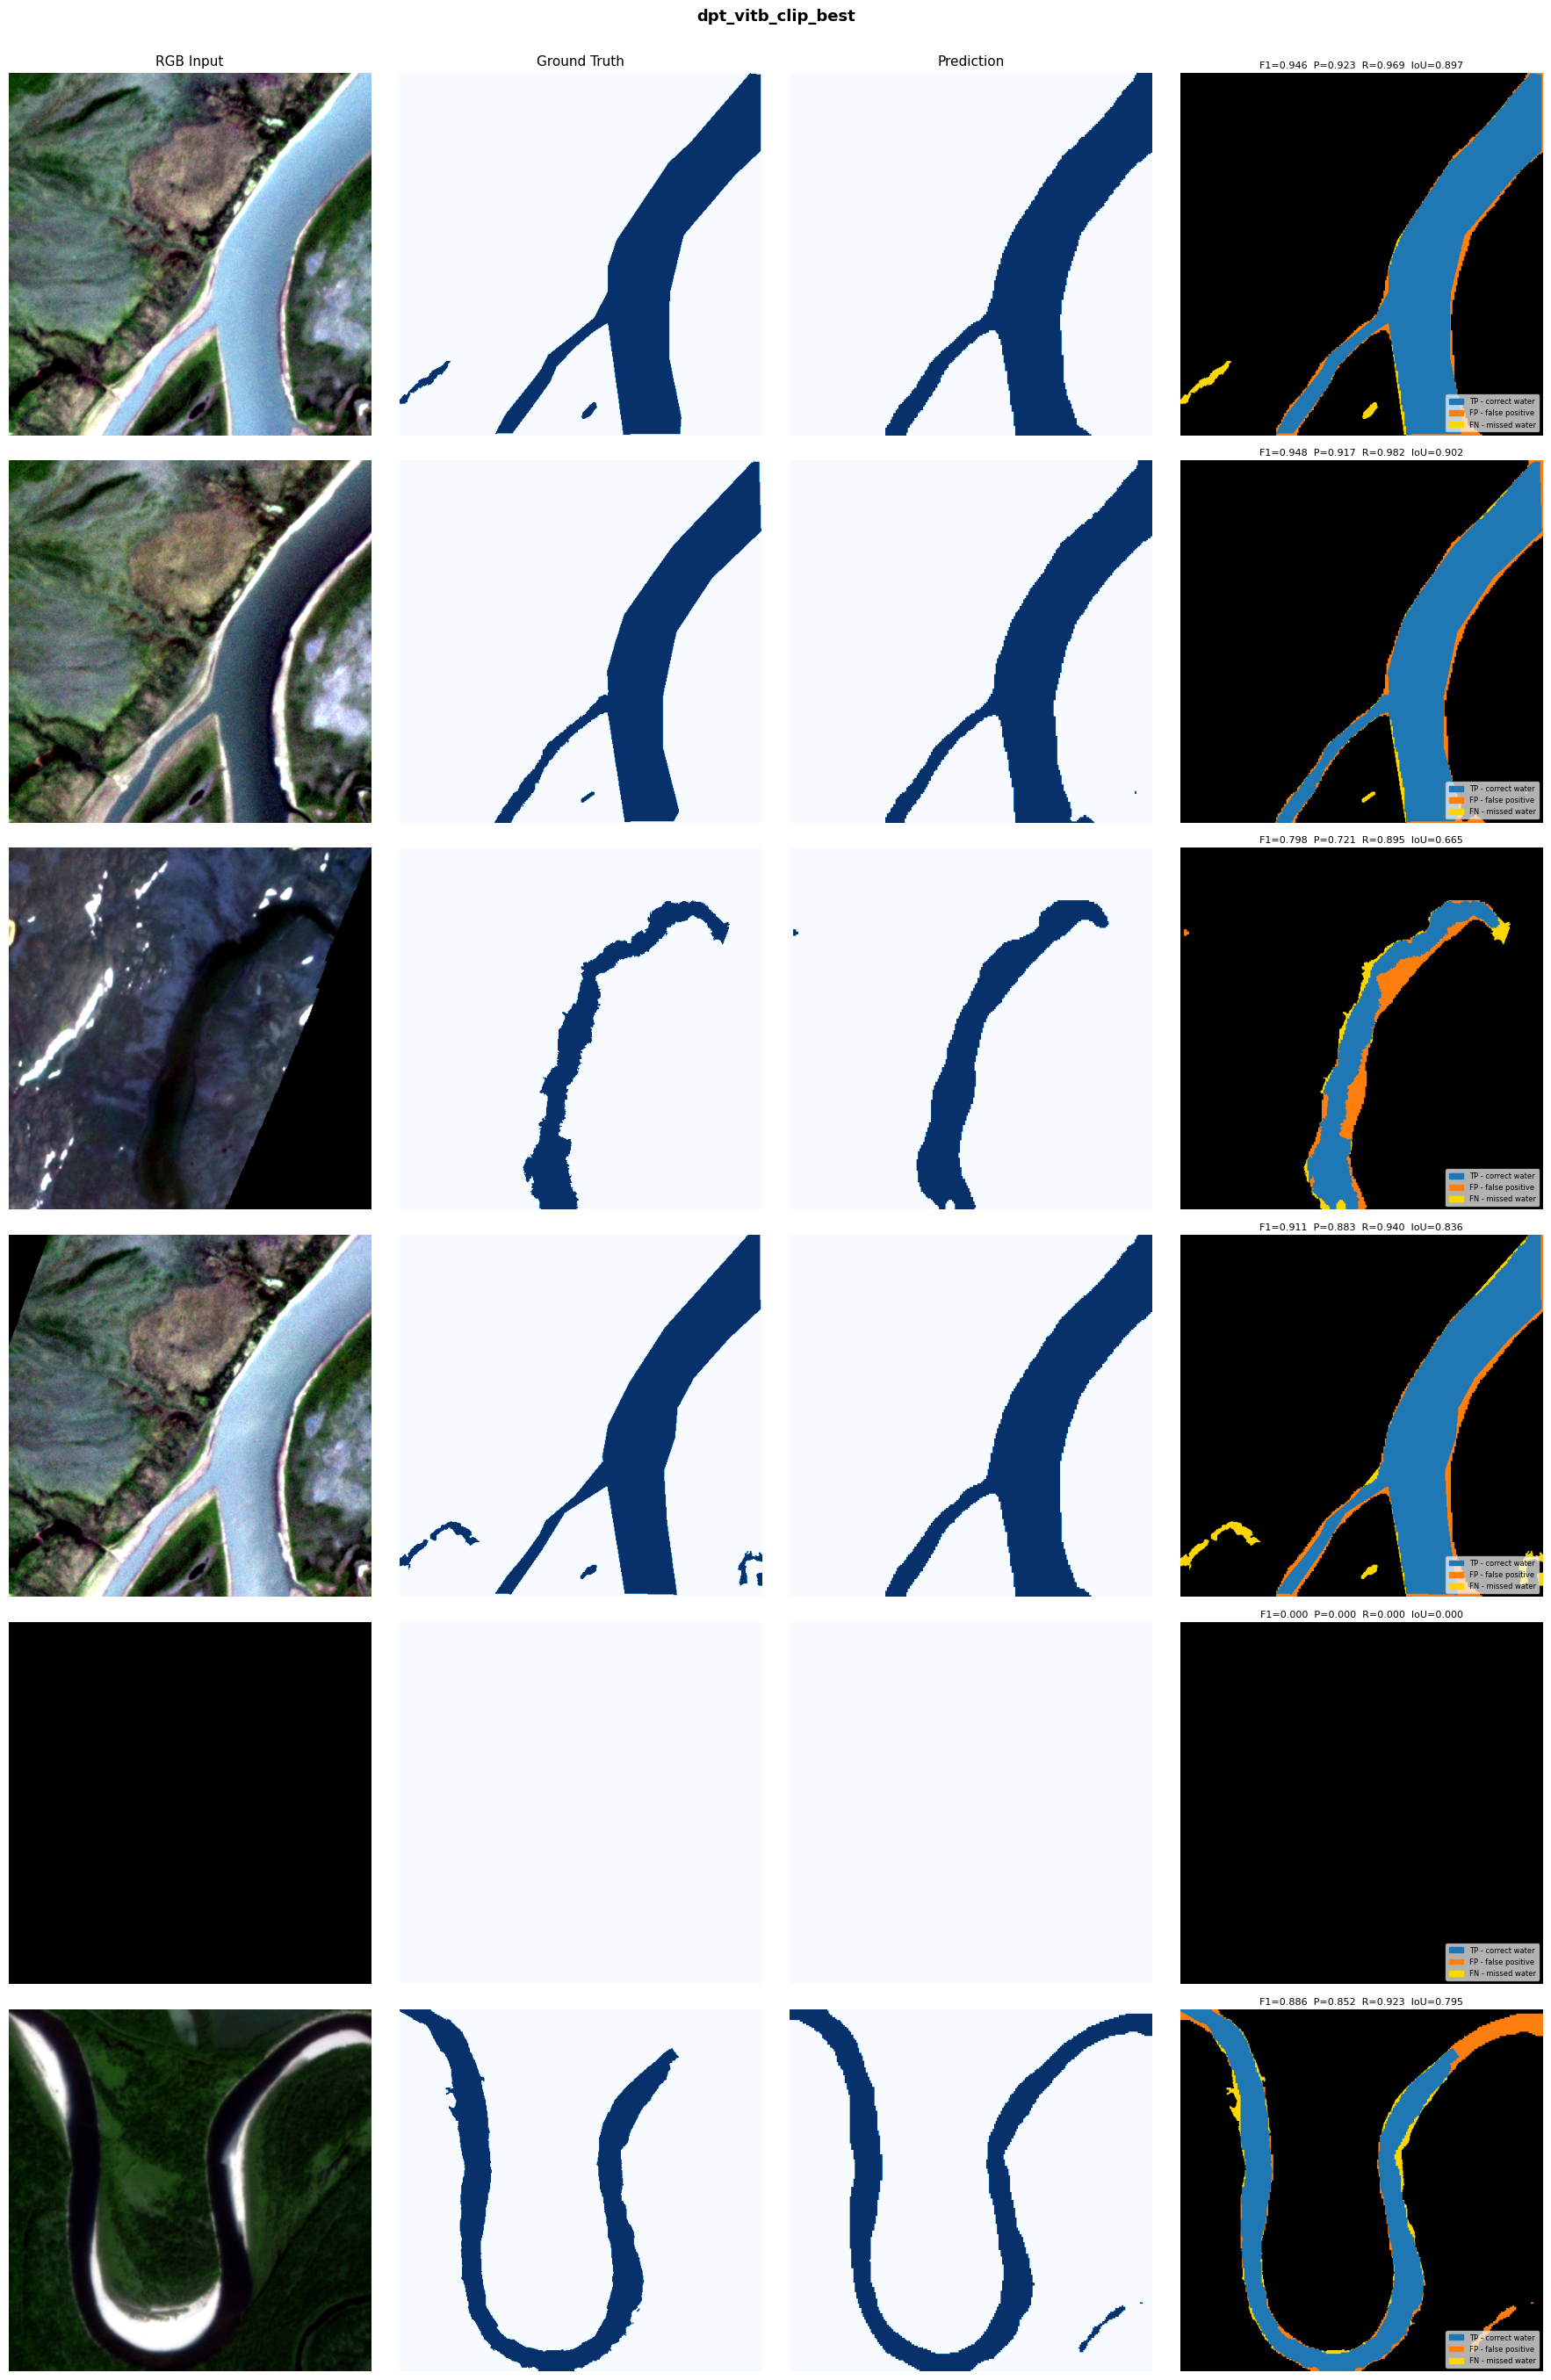

Saved to ./results/planet-test-eval/dpt_vitb_clip_best/visualization_grid.png


In [14]:
import os, glob, random
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import pandas as pd

# ── CONFIG ──────────────────────────────────────────────────────────────────
N_SAMPLES   = 6          # number of rows to show
RANDOM_SEED = 42
# ────────────────────────────────────────────────────────────────────────────

random.seed(RANDOM_SEED)

# Saved prediction masks (written by --to_save_imgs 1)
pred_tifs = sorted(glob.glob(os.path.join(raster_src, '*.tif')))
pred_tifs = [f for f in pred_tifs if '--gt' not in f]  # exclude GT tifs if any
print(f'Found {len(pred_tifs)} prediction masks in {raster_src}')

# Load test CSV to get ground-truth label paths
df_test = pd.read_csv(os.path.join(RIVERSCOPE_DATASET_DIR, 'test.csv'))

def get_gt_path_for_pred(pred_fp, df, dataset_root):
    """Match a prediction .tif back to its ground-truth label via the CSV."""
    # pred filename is reach--tile--filename.tif (joined with --)
    parts = os.path.basename(pred_fp).replace('.tif','').split('--')
    # Try to find the matching row by reach_id or by path fragment
    for _, row in df.iterrows():
        lp = str(row['label_path'])
        if all(p in lp for p in parts[-2:]):   # match last 2 path segments
            return os.path.join(dataset_root, lp)
    return None

def get_input_path_for_pred(pred_fp, df, dataset_root):
    """Match a prediction .tif back to its normalized input image via the CSV."""
    parts = os.path.basename(pred_fp).replace('.tif','').split('--')
    for _, row in df.iterrows():
        ip = str(row['normalized_planetscope_path'])
        if all(p in ip for p in parts[-2:]):
            return os.path.join(dataset_root, ip)
    return None

def read_tif_rgb(fp):
    """Read a multi-band GeoTIFF and return a normalised uint8 RGB array."""
    with rasterio.open(fp) as src:
        data = src.read()   # (bands, H, W)
    # Use first 3 bands (R, G, B); clip and normalise to 0-255
    rgb = data[:3].astype(np.float32)
    for i in range(rgb.shape[0]):
        p2, p98 = np.percentile(rgb[i][rgb[i] > 0], (2, 98)) if rgb[i].max() > 0 else (0, 1)
        rgb[i] = np.clip((rgb[i] - p2) / (p98 - p2 + 1e-8), 0, 1)
    return np.transpose(rgb, (1, 2, 0))

def read_mask(fp):
    """Read a single-band mask GeoTIFF and return a binary 2-D array."""
    with rasterio.open(fp) as src:
        mask = src.read(1).astype(np.float32)
    return (mask > 0.5).astype(np.uint8)

def compute_metrics(gt, pred):
    TP = np.sum((gt == 1) & (pred == 1))
    FP = np.sum((gt == 0) & (pred == 1))
    FN = np.sum((gt == 1) & (pred == 0))
    TN = np.sum((gt == 0) & (pred == 0))
    eps = 1e-7
    prec = TP / (TP + FP + eps)
    rec  = TP / (TP + FN + eps)
    f1   = 2 * prec * rec / (prec + rec + eps)
    iou  = TP / (TP + FP + FN + eps)
    return f1, prec, rec, iou

def make_overlay(gt, pred):
    """RGB overlay: blue=TP, orange=FP, yellow=FN, black=TN."""
    h, w = gt.shape
    overlay = np.zeros((h, w, 3), dtype=np.uint8)
    TP_mask = (gt == 1) & (pred == 1)
    FP_mask = (gt == 0) & (pred == 1)
    FN_mask = (gt == 1) & (pred == 0)
    overlay[TP_mask] = [31,  119, 180]   # blue
    overlay[FP_mask] = [255, 127,  14]   # orange
    overlay[FN_mask] = [255, 215,   0]   # yellow
    return overlay

# Sample N predictions
sample_preds = random.sample(pred_tifs, min(N_SAMPLES, len(pred_tifs)))

fig, axes = plt.subplots(len(sample_preds), 4,
                         figsize=(18, 4.5 * len(sample_preds)))
if len(sample_preds) == 1:
    axes = [axes]

# Global title
ckpt_label = os.path.basename(CKPT_VITB_CLIP).replace('.pth.tar','')
fig.suptitle(f'{ckpt_label}', fontsize=13, fontweight='bold', y=1.002)

col_titles = ['RGB Input', 'Ground Truth', 'Prediction', 'Overlay (TP/FP/FN)']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=11, pad=6)

for row_idx, pred_fp in enumerate(sample_preds):
    ax_rgb, ax_gt, ax_pred, ax_ov = axes[row_idx]

    pred_mask = read_mask(pred_fp)

    gt_fp    = get_gt_path_for_pred(pred_fp, df_test, RIVERSCOPE_DATASET_DIR)
    input_fp = get_input_path_for_pred(pred_fp, df_test, RIVERSCOPE_DATASET_DIR)

    # ── RGB input ──
    if input_fp and os.path.exists(input_fp):
        rgb = read_tif_rgb(input_fp)
        ax_rgb.imshow(rgb)
    else:
        ax_rgb.text(0.5, 0.5, 'input not found', ha='center', va='center',
                    transform=ax_rgb.transAxes, color='red')
        ax_rgb.set_facecolor('black')

    # ── Ground truth ──
    if gt_fp and os.path.exists(gt_fp):
        gt_mask = read_mask(gt_fp)
        ax_gt.imshow(gt_mask, cmap='Blues', vmin=0, vmax=1)
    else:
        gt_mask = None
        ax_gt.text(0.5, 0.5, 'GT not found', ha='center', va='center',
                   transform=ax_gt.transAxes, color='red')

    # ── Prediction ──
    ax_pred.imshow(pred_mask, cmap='Blues', vmin=0, vmax=1)

    # ── Overlay + metrics ──
    if gt_mask is not None:
        f1, prec, rec, iou = compute_metrics(gt_mask, pred_mask)
        overlay = make_overlay(gt_mask, pred_mask)
        ax_ov.imshow(overlay)
        ax_ov.set_title(
            f'F1={f1:.3f}  P={prec:.3f}  R={rec:.3f}  IoU={iou:.3f}',
            fontsize=8, pad=4
        )
        # Legend
        patches = [
            mpatches.Patch(color=np.array([31,119,180])/255,  label='TP - correct water'),
            mpatches.Patch(color=np.array([255,127,14])/255,  label='FP - false positive'),
            mpatches.Patch(color=np.array([255,215,0])/255,   label='FN - missed water'),
        ]
        ax_ov.legend(handles=patches, loc='lower right', fontsize=6,
                     framealpha=0.7, markerscale=0.8)
    else:
        ax_ov.imshow(pred_mask, cmap='Blues', vmin=0, vmax=1)

    for ax in [ax_rgb, ax_gt, ax_pred, ax_ov]:
        ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(raster_src, 'visualization_grid.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {raster_src}/visualization_grid.png')

In [16]:
# ── Re-run vitb_clip with image saving ──
cmd_save = [
    sys.executable, 'water_eval_planet.py',
    '--data_dir', RIVERSCOPE_DATASET_DIR,
    '--ckpt_path', CKPT_VITL,
    '--thresh', '0.3',
    '--batch_size', '4',
    '--to_save_imgs', '1',      # <-- save masks
    '--out', './results/planet-test-eval',
]
subprocess.run(cmd_save)

CompletedProcess(args=['/usr/bin/python3', 'water_eval_planet.py', '--data_dir', '/content/drive/MyDrive/CS682/project/RiverScope_dataset', '--ckpt_path', '/content/drive/MyDrive/CS682/project/riverscope-models/checkpoints/dpt_vitl_best.pth.tar', '--thresh', '0.3', '--batch_size', '4', '--to_save_imgs', '1', '--out', './results/planet-test-eval'], returncode=0)

In [17]:
# Determine the checkpoint folder name (eval script uses ckpt filename without extension)
ckpt_name = os.path.basename(CKPT_VITL).replace('.pth.tar', '')
raster_src = f'./results/planet-test-eval/{ckpt_name}'

print(f'Running river width estimation on: {raster_src}')

cmd_width = [
    sys.executable, 'river_width_estimate.py',
    '--satellite_src', 'planet',
    '--raster_src', raster_src,
    '--is_gt', '0',
    '--raster_idx', '-1',
    '--out', './results/planet-test-eval-width',
]
subprocess.run(cmd_width)

print('\nWidth estimation results saved to: ./results/planet-test-eval-width')
print('Compare against GT widths at:')
print(f'  {RIVERSCOPE_DATASET_DIR}/PlanetScope/derived_gt_widths-test.csv')

Running river width estimation on: ./results/planet-test-eval/dpt_vitl_best

Width estimation results saved to: ./results/planet-test-eval-width
Compare against GT widths at:
  /content/drive/MyDrive/CS682/project/RiverScope_dataset/PlanetScope/derived_gt_widths-test.csv


In [18]:
import os, glob, random
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import pandas as pd

# ── CONFIG ──────────────────────────────────────────────────────────────────
N_SAMPLES   = 6          # number of rows to show
RANDOM_SEED = 42
# ────────────────────────────────────────────────────────────────────────────

random.seed(RANDOM_SEED)

# Saved prediction masks (written by --to_save_imgs 1)
pred_tifs = sorted(glob.glob(os.path.join(raster_src, '*.tif')))
pred_tifs = [f for f in pred_tifs if '--gt' not in f]  # exclude GT tifs if any
print(f'Found {len(pred_tifs)} prediction masks in {raster_src}')

# Load test CSV to get ground-truth label paths
df_test = pd.read_csv(os.path.join(RIVERSCOPE_DATASET_DIR, 'test.csv'))

def get_gt_path_for_pred(pred_fp, df, dataset_root):
    """Match a prediction .tif back to its ground-truth label via the CSV."""
    # pred filename is reach--tile--filename.tif (joined with --)
    parts = os.path.basename(pred_fp).replace('.tif','').split('--')
    # Try to find the matching row by reach_id or by path fragment
    for _, row in df.iterrows():
        lp = str(row['label_path'])
        if all(p in lp for p in parts[-2:]):   # match last 2 path segments
            return os.path.join(dataset_root, lp)
    return None

def get_input_path_for_pred(pred_fp, df, dataset_root):
    """Match a prediction .tif back to its normalized input image via the CSV."""
    parts = os.path.basename(pred_fp).replace('.tif','').split('--')
    for _, row in df.iterrows():
        ip = str(row['normalized_planetscope_path'])
        if all(p in ip for p in parts[-2:]):
            return os.path.join(dataset_root, ip)
    return None

def read_tif_rgb(fp):
    """Read a multi-band GeoTIFF and return a normalised uint8 RGB array."""
    with rasterio.open(fp) as src:
        data = src.read()   # (bands, H, W)
    # Use first 3 bands (R, G, B); clip and normalise to 0-255
    rgb = data[:3].astype(np.float32)
    for i in range(rgb.shape[0]):
        p2, p98 = np.percentile(rgb[i][rgb[i] > 0], (2, 98)) if rgb[i].max() > 0 else (0, 1)
        rgb[i] = np.clip((rgb[i] - p2) / (p98 - p2 + 1e-8), 0, 1)
    return np.transpose(rgb, (1, 2, 0))

def read_mask(fp):
    """Read a single-band mask GeoTIFF and return a binary 2-D array."""
    with rasterio.open(fp) as src:
        mask = src.read(1).astype(np.float32)
    return (mask > 0.5).astype(np.uint8)

def compute_metrics(gt, pred):
    TP = np.sum((gt == 1) & (pred == 1))
    FP = np.sum((gt == 0) & (pred == 1))
    FN = np.sum((gt == 1) & (pred == 0))
    TN = np.sum((gt == 0) & (pred == 0))
    eps = 1e-7
    prec = TP / (TP + FP + eps)
    rec  = TP / (TP + FN + eps)
    f1   = 2 * prec * rec / (prec + rec + eps)
    iou  = TP / (TP + FP + FN + eps)
    return f1, prec, rec, iou

def make_overlay(gt, pred):
    """RGB overlay: blue=TP, orange=FP, yellow=FN, black=TN."""
    h, w = gt.shape
    overlay = np.zeros((h, w, 3), dtype=np.uint8)
    TP_mask = (gt == 1) & (pred == 1)
    FP_mask = (gt == 0) & (pred == 1)
    FN_mask = (gt == 1) & (pred == 0)
    overlay[TP_mask] = [31,  119, 180]   # blue
    overlay[FP_mask] = [255, 127,  14]   # orange
    overlay[FN_mask] = [255, 215,   0]   # yellow
    return overlay

# Sample N predictions
sample_preds = random.sample(pred_tifs, min(N_SAMPLES, len(pred_tifs)))

fig, axes = plt.subplots(len(sample_preds), 4,
                         figsize=(18, 4.5 * len(sample_preds)))
if len(sample_preds) == 1:
    axes = [axes]

# Global title
ckpt_label = os.path.basename(CKPT_VITL).replace('.pth.tar','')
fig.suptitle(f'{ckpt_label}', fontsize=13, fontweight='bold', y=1.002)

col_titles = ['RGB Input', 'Ground Truth', 'Prediction', 'Overlay (TP/FP/FN)']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=11, pad=6)

for row_idx, pred_fp in enumerate(sample_preds):
    ax_rgb, ax_gt, ax_pred, ax_ov = axes[row_idx]

    pred_mask = read_mask(pred_fp)

    gt_fp    = get_gt_path_for_pred(pred_fp, df_test, RIVERSCOPE_DATASET_DIR)
    input_fp = get_input_path_for_pred(pred_fp, df_test, RIVERSCOPE_DATASET_DIR)

    # ── RGB input ──
    if input_fp and os.path.exists(input_fp):
        rgb = read_tif_rgb(input_fp)
        ax_rgb.imshow(rgb)
    else:
        ax_rgb.text(0.5, 0.5, 'input not found', ha='center', va='center',
                    transform=ax_rgb.transAxes, color='red')
        ax_rgb.set_facecolor('black')

    # ── Ground truth ──
    if gt_fp and os.path.exists(gt_fp):
        gt_mask = read_mask(gt_fp)
        ax_gt.imshow(gt_mask, cmap='Blues', vmin=0, vmax=1)
    else:
        gt_mask = None
        ax_gt.text(0.5, 0.5, 'GT not found', ha='center', va='center',
                   transform=ax_gt.transAxes, color='red')

    # ── Prediction ──
    ax_pred.imshow(pred_mask, cmap='Blues', vmin=0, vmax=1)

    # ── Overlay + metrics ──
    if gt_mask is not None:
        f1, prec, rec, iou = compute_metrics(gt_mask, pred_mask)
        overlay = make_overlay(gt_mask, pred_mask)
        ax_ov.imshow(overlay)
        ax_ov.set_title(
            f'F1={f1:.3f}  P={prec:.3f}  R={rec:.3f}  IoU={iou:.3f}',
            fontsize=8, pad=4
        )
        # Legend
        patches = [
            mpatches.Patch(color=np.array([31,119,180])/255,  label='TP - correct water'),
            mpatches.Patch(color=np.array([255,127,14])/255,  label='FP - false positive'),
            mpatches.Patch(color=np.array([255,215,0])/255,   label='FN - missed water'),
        ]
        ax_ov.legend(handles=patches, loc='lower right', fontsize=6,
                     framealpha=0.7, markerscale=0.8)
    else:
        ax_ov.imshow(pred_mask, cmap='Blues', vmin=0, vmax=1)

    for ax in [ax_rgb, ax_gt, ax_pred, ax_ov]:
        ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(raster_src, 'visualization_grid.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {raster_src}/visualization_grid.png')

Output hidden; open in https://colab.research.google.com to view.

## 11. (Optional) Training From Scratch

To re-train instead of using pre-trained checkpoints, you also need the MoCoV3 backbone weights.

1. Download backbone checkpoints: [Google Drive](https://drive.google.com/drive/folders/1NNz4Qg2Ao62GUe_NAllv2BjSHYVJegf_?usp=drive_link)
2. Place in `riverscope-models/checkpoints/moco_v3/`
3. Run training (see cells below)

Optimal LRs from `script_train_planet.sh`:

| Model | Backbone | LR |
|-------|----------|---------|
| dpt | vitb_clip | 1e-4 |
| dpt | vitl | 5e-5 |

In [ ]:
# ── TRAINING: DPT + vitb_clip ──────────────────────────────────────────────
# ⚠️ This takes ~hours on a single GPU. Adjust --epochs as needed.
# The script uses DDP; for single-GPU Colab, world-size=1 rank=0 is correct.

train_cmd_vitb_clip = [
    sys.executable, 'train_planet.py',
    '--dist-url', 'tcp://127.0.0.1:8001',
    '--dist-backend', 'nccl',
    '--multiprocessing-distributed',
    '--world-size', '1',
    '--rank', '0',
    '--data_dir', RIVERSCOPE_DATASET_DIR,
    '--segment_model', 'dpt',
    '--backbone', 'vitb_clip',
    '--head', 'no_head',
    '--resize_size', '224',
    '--adaptor', 'linear',
    '--lr', '1e-4',
]

print('Training command (DPT vitb_clip):')
print(' '.join(train_cmd_vitb_clip))
# Uncomment to run:
# subprocess.run(train_cmd_vitb_clip)

In [ ]:
# ── TRAINING: DPT + vitl ───────────────────────────────────────────────────
# ⚠️ vitl is ~3x larger. Requires ≥40 GB VRAM for default batch size.
# Use --batch-size 4 or 2 on smaller GPUs.

train_cmd_vitl = [
    sys.executable, 'train_planet.py',
    '--dist-url', 'tcp://127.0.0.1:8002',
    '--dist-backend', 'nccl',
    '--multiprocessing-distributed',
    '--world-size', '1',
    '--rank', '0',
    '--data_dir', RIVERSCOPE_DATASET_DIR,
    '--segment_model', 'dpt',
    '--backbone', 'vitl',
    '--head', 'no_head',
    '--resize_size', '224',
    '--adaptor', 'linear',
    '--lr', '5e-5',
]

print('Training command (DPT vitl):')
print(' '.join(train_cmd_vitl))
# Uncomment to run:
# subprocess.run(train_cmd_vitl)

## Troubleshooting

### CUDA version mismatch
If `torch.cuda.is_available()` returns False or you get CUDA errors, force-reinstall torch for your Colab CUDA:
```python
!nvcc --version   # check CUDA version
# Then install matching torch, e.g. for CUDA 12.1:
!pip install torch==2.6.0+cu121 torchvision==0.21.0+cu121 --extra-index-url https://download.pytorch.org/whl/cu121
```

### OOM (Out of Memory) on ViT-L
```python
# Add --batch_size 2 to the eval command
# Or enable gradient checkpointing (requires patching models/dpt.py)
import torch
torch.cuda.empty_cache()
```

### `gdown` quota exceeded
Google Drive has per-day download quotas. If gdown fails:
1. Open the Drive link directly in browser and add to your own Drive
2. Then mount Drive and update `CKPT_VITB_CLIP` / `CKPT_VITL` paths

### `strict=True` state dict mismatch
The eval script strips the `module.` prefix from DDP-wrapped state dicts automatically. If you still get key mismatches, inspect:
```python
ckpt = torch.load(CKPT_VITB_CLIP, map_location='cpu', weights_only=False)
print(list(ckpt['state_dict'].keys())[:5])
```

### Reproducibility note
The paper reports mean ± std over **5 independent runs**. A single evaluation with the provided best checkpoint reproduces the best-run result, not the mean. Differences of ~1% F1 from the reported mean are expected.